In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
solutions = np.load("./results-1d/complete_results.npy")[:, :, :, ::-1]
meshes = np.load("./results-1d/mesh_points.npy").reshape(-1)[::-1]
Lp_values = np.load("./results-1d/Lp_values.npy")
times = np.load("./results-1d/times.npy")
tmin, tmax = times.min(), times.max()
xmin, xmax = meshes.min()*1e6, meshes.max()*1e6  # convert to micrometers
solutions.shape, meshes.shape, Lp_values.shape, times.shape

((12, 101, 2, 101), (101,), (12,), (101,))

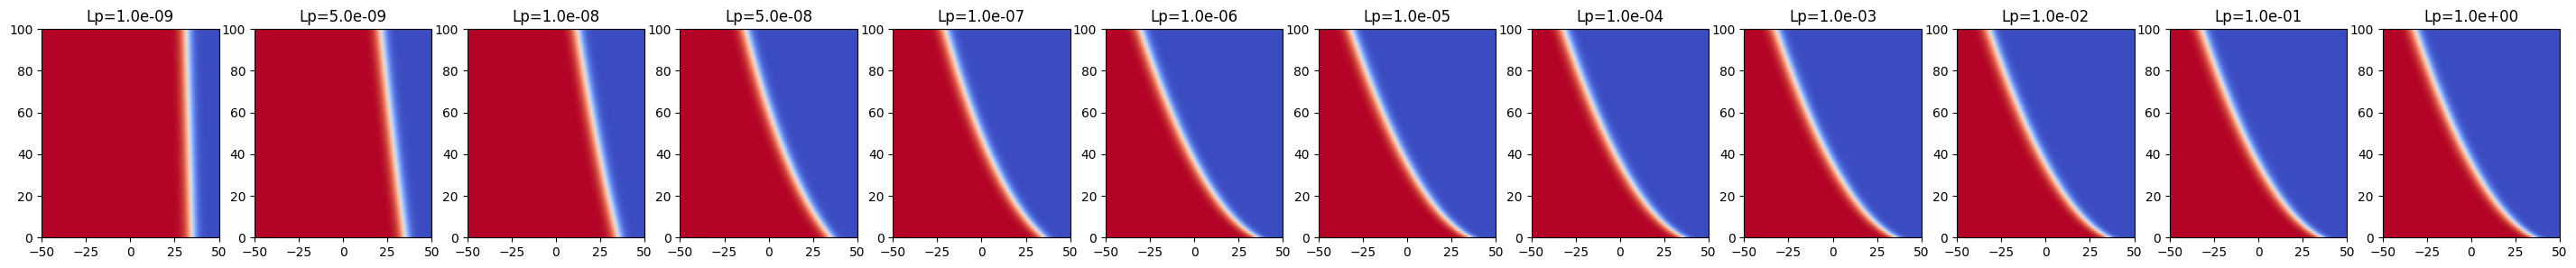

In [3]:
fig, axes = plt.subplots(1, len(Lp_values), figsize=(3*len(Lp_values), 3))
for i, Lp in enumerate(Lp_values):
    solution = solutions[i]  # shape: (time, channel, points)
    ax = axes[i]
    phi = solution[:, 0, :]  # shape: (time, points)
    c = solution[:, 1, :]    # shape: (time, points)
    im = ax.imshow(phi, extent=[xmin, xmax, tmin, tmax], aspect='auto',
                   origin='lower', cmap='coolwarm')
    ax.set_title(f'Lp={Lp:.1e}')

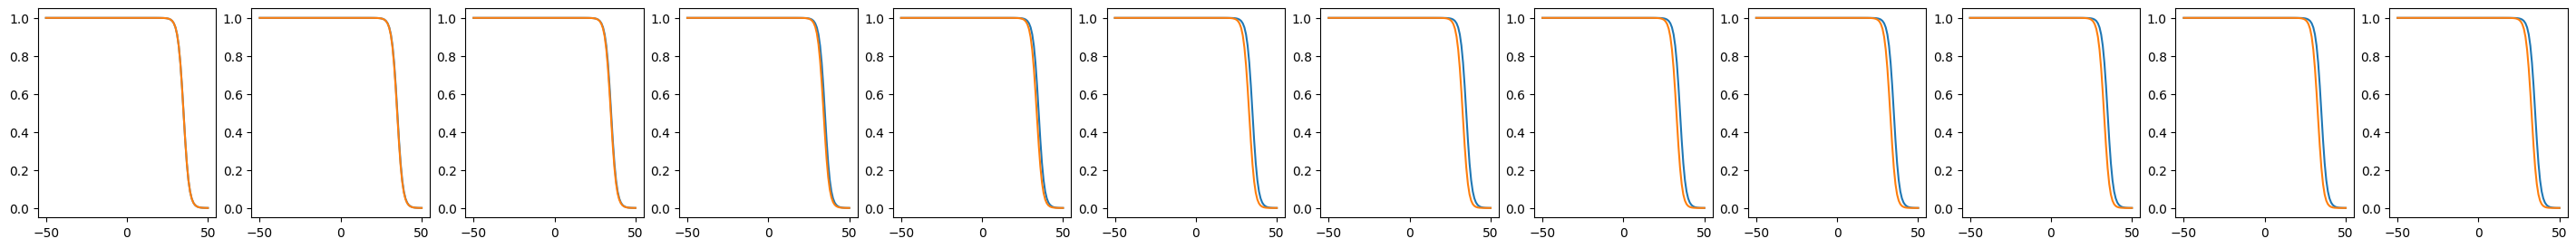

In [4]:
fig, axes = plt.subplots(1, len(Lp_values), figsize=(3*len(Lp_values), 3))
for i, Lp in enumerate(Lp_values):
    solution = solutions[i]  # shape: (time, channel, points)
    ax = axes[i]
    phi = solution[:, 0, :]  # shape: (time, points)
    c = solution[:, 1, :]    # shape: (time, points)
    ax.plot(meshes*1e6, phi[0, :], label='t=0s')
    ax.plot(meshes*1e6, phi[1, :], label='t=0s')


In [5]:
# make a whole dataset as: [time*num_Lp, channel+1, points]
# Lp values are viewed as constant in another channel
num_Lp = len(Lp_values)
num_time = times.shape[0]
num_points = meshes.shape[0]
Xs = np.zeros(((num_time-1)*num_Lp, 5, num_points))  # input: phi and Lp
Ys = np.zeros(((num_time-1)*num_Lp, 2, num_points))    # output: c

for i in range(num_Lp):
    Xs[i*(num_time-1):(i+1)*(num_time-1), 0, :] = solutions[i, :-1, 0, :]  # phi
    Xs[i*(num_time-1):(i+1)*(num_time-1), 1, :] = solutions[i, :-1, 1, :]  # c
    Xs[i*(num_time-1):(i+1)*(num_time-1), 2, :] = -np.log10(Lp_values[i])-5
    meshes_repeated = np.tile(meshes, (num_time-1, 1))
    Xs[i*(num_time-1):(i+1)*(num_time-1), 3, :] = meshes_repeated * 1e5 
    times_repeated = np.tile(times[:-1].reshape(-1, 1), (1, num_points))
    Xs[i*(num_time-1):(i+1)*(num_time-1), 4, :] = times_repeated / 100
    Ys[i*(num_time-1):(i+1)*(num_time-1), 0, :] = solutions[i, 1:, 0, :]  # phi
    Ys[i*(num_time-1):(i+1)*(num_time-1), 1, :] = solutions[i, 1:, 1, :]  # c
Xs.shape, Ys.shape

((1200, 5, 101), (1200, 2, 101))

In [8]:
np.savez("dataset_1d_complete.npz", Xs=Xs, Ys=Ys, 
         meshes=meshes * 1e5,
         Lp_values=-np.log10(Lp_values)-5, 
         times=times / 100)
         

In [10]:
Xs.shape, Ys.shape

((1200, 5, 101), (1200, 2, 101))